# 🫀 Logistic Regression - Tuning & Final Model

- **Author**: Laura Granda
- **Date**: 2026-03-15
- **Input**: `data/03_primary/corazon_explored.parquet`
- **Output**: `models/logistic_regression_v1.pkl`

In [12]:
import shutil
import sys
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from joblib import dump
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import GridSearchCV, learning_curve, train_test_split
from sklearn.pipeline import Pipeline

# Add project root to python path
sys.path.append(str(Path.cwd().resolve().parents[1]))
from src.pipelines.feature_pipeline.build_features import create_preprocessor

## 💾 Load data

In [13]:
DATA_PATH: Path = (
    Path.cwd().resolve().parents[1] / "data" / "03_primary" / "corazon_explored.parquet"
)
NUMERIC_FEATURES: list[str] = ["age", "max_hr", "old_peak"]
CATEGORICAL_FEATURES: list[str] = ["chest_pain", "sex"]
ORDINAL_FEATURES: list[str] = ["thal", "slope", "ca", "exang"]
FEATURES: list[str] = [*NUMERIC_FEATURES, *CATEGORICAL_FEATURES, *ORDINAL_FEATURES]
TARGET: str = "disease"
CATEGORICAL_ORDINAL: list[str] = [*CATEGORICAL_FEATURES, *ORDINAL_FEATURES]

df: pd.DataFrame = pd.read_parquet(DATA_PATH)
print(f"Shape before dedup: {df.shape}")
df = df.drop_duplicates()
print(f"Shape after dedup:  {df.shape}")
df = df[[*FEATURES, TARGET]]
for col in CATEGORICAL_ORDINAL:
    df[col] = df[col].astype(str)

print(f"Final shape: {df.shape}")

Shape before dedup: (2919, 14)
Shape after dedup:  (480, 14)
Final shape: (480, 10)


## ✂️ Train / Test split

In [14]:
X: pd.DataFrame = df[FEATURES]
y: pd.Series = df[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"X_train: {X_train.shape} | X_test: {X_test.shape}")
print(f"y_train: {y_train.shape} | y_test: {y_test.shape}")

X_train: (384, 9) | X_test: (96, 9)
y_train: (384,) | y_test: (96,)


## ⚙️ Hyperparameter Tuning

In [15]:
RANDOM_STATE: int = 42

preprocessor = create_preprocessor()
pipeline: Pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", LogisticRegression(solver="liblinear", random_state=RANDOM_STATE)),
    ]
)

param_grid: dict = {
    "model__penalty": ["l1", "l2"],
    "model__C": [0.01, 0.1, 0.5, 1, 5, 10],
}

grid_search: GridSearchCV = GridSearchCV(
    pipeline,
    param_grid,
    cv=5,
    scoring="recall",
    return_train_score=True,
    n_jobs=-1,
)
grid_search.fit(X_train, y_train)

print(f"Best params:  {grid_search.best_params_}")
print(f"Best recall:  {grid_search.best_score_:.4f}")

/home/lauragranda01/corazon/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/home/lauragranda01/corazon/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(
/home/lauragranda01/corazon/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of pe

Best params:  {'model__C': 1, 'model__penalty': 'l2'}
Best recall:  0.7827


/home/lauragranda01/corazon/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/home/lauragranda01/corazon/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(
/home/lauragranda01/corazon/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of pe

## 📈 Learning Curve

/home/lauragranda01/corazon/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/home/lauragranda01/corazon/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/home/lauragranda01/corazon/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will

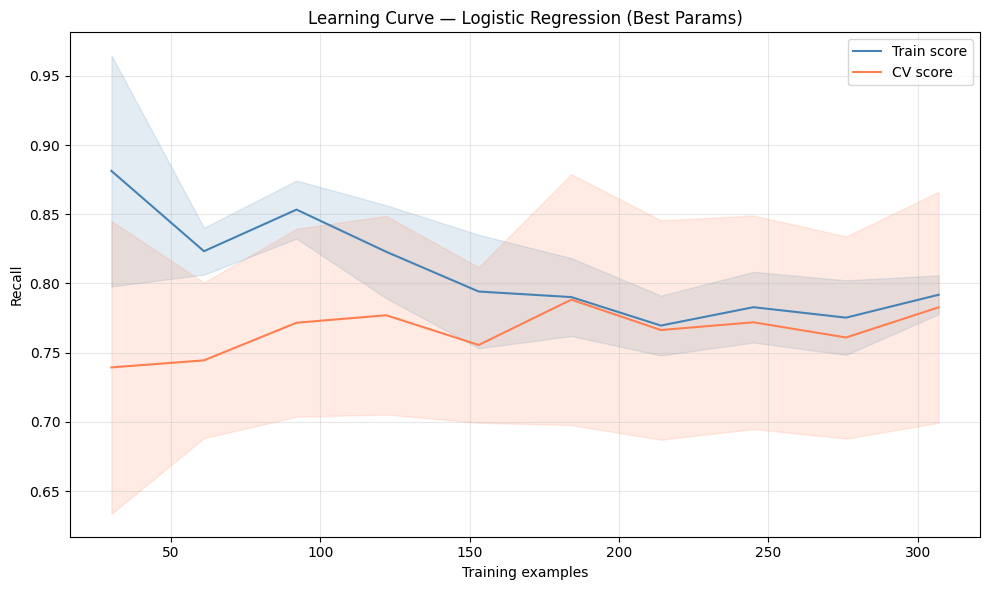

In [16]:
best_model: Pipeline = grid_search.best_estimator_

train_sizes, train_scores, cv_scores = learning_curve(
    best_model,
    X_train,
    y_train,
    cv=5,
    scoring="recall",
    train_sizes=np.linspace(0.1, 1.0, 10),
)

train_mean: np.ndarray = train_scores.mean(axis=1)
train_std: np.ndarray = train_scores.std(axis=1)
cv_mean: np.ndarray = cv_scores.mean(axis=1)
cv_std: np.ndarray = cv_scores.std(axis=1)

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(train_sizes, train_mean, label="Train score", color="steelblue")
ax.fill_between(
    train_sizes,
    train_mean - train_std,
    train_mean + train_std,
    alpha=0.15,
    color="steelblue",
)
ax.plot(train_sizes, cv_mean, label="CV score", color="coral")
ax.fill_between(train_sizes, cv_mean - cv_std, cv_mean + cv_std, alpha=0.15, color="coral")
ax.set_xlabel("Training examples")
ax.set_ylabel("Recall")
ax.set_title("Learning Curve — Logistic Regression (Best Params)")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 💾 Save Best Model

In [17]:
MODELS_PATH: Path = Path.cwd().resolve().parents[1] / "models"
MODELS_PATH.mkdir(parents=True, exist_ok=True)

MODEL_PATH: Path = MODELS_PATH / "logistic_regression_v1.pkl"
joblib.dump(best_model, MODEL_PATH)
print(f"Model saved to: {MODEL_PATH}")

Model saved to: /home/lauragranda01/corazon/models/logistic_regression_v1.pkl


## 🧪 Test Set Evaluation

In [18]:
# Load the saved model
loaded_model: Pipeline = joblib.load(MODEL_PATH)
print(f"✓ Model loaded from: {MODEL_PATH}")

# Make predictions on test set
y_test_pred: np.ndarray = loaded_model.predict(X_test)
y_test_proba: np.ndarray = loaded_model.predict_proba(X_test)[:, 1]

# Calculate metrics
test_accuracy: float = accuracy_score(y_test, y_test_pred)
test_precision: float = precision_score(y_test, y_test_pred, zero_division=0)
test_recall: float = recall_score(y_test, y_test_pred, zero_division=0)
test_f1: float = f1_score(y_test, y_test_pred, zero_division=0)
test_roc: float = roc_auc_score(y_test, y_test_proba)

# Display test metrics
print("\n" + "=" * 70)
print("TEST SET METRICS")
print("=" * 70)
print(f"Accuracy:  {test_accuracy:.4f}")
print(f"Precision: {test_precision:.4f}")
print(f"Recall:    {test_recall:.4f}")
print(f"F1-Score:  {test_f1:.4f}")
print(f"ROC-AUC:   {test_roc:.4f}")

print("\n" + "=" * 70)
print("CLASSIFICATION REPORT")
print("=" * 70)
print(classification_report(y_test, y_test_pred, target_names=["No Disease", "Disease"]))

✓ Model loaded from: /home/lauragranda01/corazon/models/logistic_regression_v1.pkl

TEST SET METRICS
Accuracy:  0.8021
Precision: 0.7547
Recall:    0.8696
F1-Score:  0.8081
ROC-AUC:   0.8839

CLASSIFICATION REPORT
              precision    recall  f1-score   support

  No Disease       0.86      0.74      0.80        50
     Disease       0.75      0.87      0.81        46

    accuracy                           0.80        96
   macro avg       0.81      0.80      0.80        96
weighted avg       0.81      0.80      0.80        96



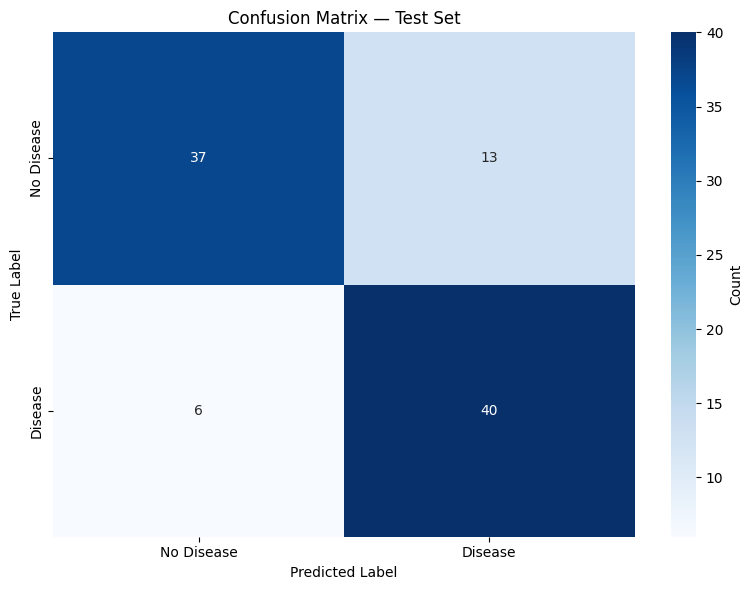


Confusion Matrix Breakdown:
True Negatives (TN):  37
False Positives (FP): 13
False Negatives (FN): 6
True Positives (TP):  40

Specificity: 0.7400
Sensitivity: 0.8696


In [19]:
# Confusion Matrix
cm: np.ndarray = confusion_matrix(y_test, y_test_pred)

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No Disease", "Disease"],
    yticklabels=["No Disease", "Disease"],
    cbar_kws={"label": "Count"},
    ax=ax,
)
ax.set_title("Confusion Matrix — Test Set")
ax.set_ylabel("True Label")
ax.set_xlabel("Predicted Label")
plt.tight_layout()
plt.show()

# Print confusion matrix breakdown
tn, fp, fn, tp = cm.ravel()
print("\nConfusion Matrix Breakdown:")
print(f"True Negatives (TN):  {tn}")
print(f"False Positives (FP): {fp}")
print(f"False Negatives (FN): {fn}")
print(f"True Positives (TP):  {tp}")
print(f"\nSpecificity: {tn / (tn + fp):.4f}")
print(f"Sensitivity: {tp / (tp + fn):.4f}")

## 📊 Track Experiment and Save Model (MLOps)

In [ ]:
import mlflow
import mlflow.sklearn
from mlflow.models.signature import infer_signature

# ── Paths ──────────────────────────────────────────────────────────────────
MODELS_DIR: Path = Path.cwd().resolve().parents[1] / "models"
MODELS_DIR.mkdir(parents=True, exist_ok=True)

MLFLOW_MODEL_DIR: Path = MODELS_DIR / "mlflow_lr_model_1"
if MLFLOW_MODEL_DIR.exists():
    shutil.rmtree(MLFLOW_MODEL_DIR)

# ── Metrics on training set ────────────────────────────────────────────────
y_pred: np.ndarray = best_model.predict(X_train)
y_pred_proba: np.ndarray = best_model.predict_proba(X_train)[:, 1]

metrics: dict = {
    "recall": recall_score(y_train, y_pred, zero_division=0),
    "precision": precision_score(y_train, y_pred, zero_division=0),
    "f1": f1_score(y_train, y_pred, zero_division=0),
    "auc": roc_auc_score(y_train, y_pred_proba),
}

# ── MLflow setup ───────────────────────────────────────────────────────────
mlflow.set_tracking_uri((Path.cwd().resolve().parents[1] / "mlruns").as_uri())
exp = mlflow.set_experiment(experiment_name="heart_disease_models")

# ── Run ────────────────────────────────────────────────────────────────────
with mlflow.start_run() as run:
    signature = infer_signature(X_train, best_model.predict(X_train))

    mlflow.set_tag("Training Info", "First model: Tuned Logistic Regression")
    mlflow.log_metrics(metrics)
    mlflow.log_params(grid_search.best_params_)
    mlflow.sklearn.log_model(
        sk_model=best_model,
        artifact_path="logistic_regression_model",
        signature=signature,
        input_example=X_train.head(),
        registered_model_name="first_model_lr",
    )
    print(f"Run ID: {run.info.run_id}")

# ── Save locally ───────────────────────────────────────────────────────────
mlflow.sklearn.save_model(
    sk_model=best_model,
    path=MLFLOW_MODEL_DIR,
    signature=signature,
    input_example=X_train.head(),
)
dump(best_model, MODELS_DIR / "logistic_regression_v1.joblib", protocol=5)
print(f"✓ MLflow model saved to: {MLFLOW_MODEL_DIR}")
print(f"✓ Joblib model saved to: {MODELS_DIR / 'logistic_regression_v1.joblib'}")

/home/lauragranda01/corazon/.venv/lib/python3.12/site-packages/mlflow/types/utils.py:452: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details.
  warnings.warn(
2026/03/15 20:56:24 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/03/15 20:56:24 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires ex

Run ID: 2906335b88e74d5bbac3a87b78216f4e


2026/03/15 20:56:30 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.


✓ MLflow model saved to: /home/lauragranda01/corazon/models/mlflow_lr_model_1
✓ Joblib model saved to: /home/lauragranda01/corazon/models/logistic_regression_v1.joblib
